# AI/ML-Enabled Devices Analysis (Post-2020)

In [8]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('ai-ml-enabled-devices-post-2020.csv')
df['Date of Final Decision'] = pd.to_datetime(df['Date of Final Decision'])
df['Year'] = df['Date of Final Decision'].dt.year

df.head()

,Date of Final Decision,Submission Number,Device,Company,Panel (Lead),Primary Product Code,Year
4,2025-12-22,K253664,SKOUT system,Iterative Health,Gastroenterology-Urology,QNP,2025
8,2025-12-19,K252284,eMurmur Heart AI,Csd Labs,Cardiovascular,DQD,2025
12,2025-12-18,K253516,Assert-IQ (DM5100),Abbott Medical,Cardiovascular,MXD,2025
17,2025-12-16,K252204,prolaio eVO2peak Module (Version 1.0),"Prolaio, Inc.",Cardiovascular,PPW,2025
20,2025-12-11,K253141,DeepRhythmAI,Medicalgorithmics S.A.,Cardiovascular,DQK,2025


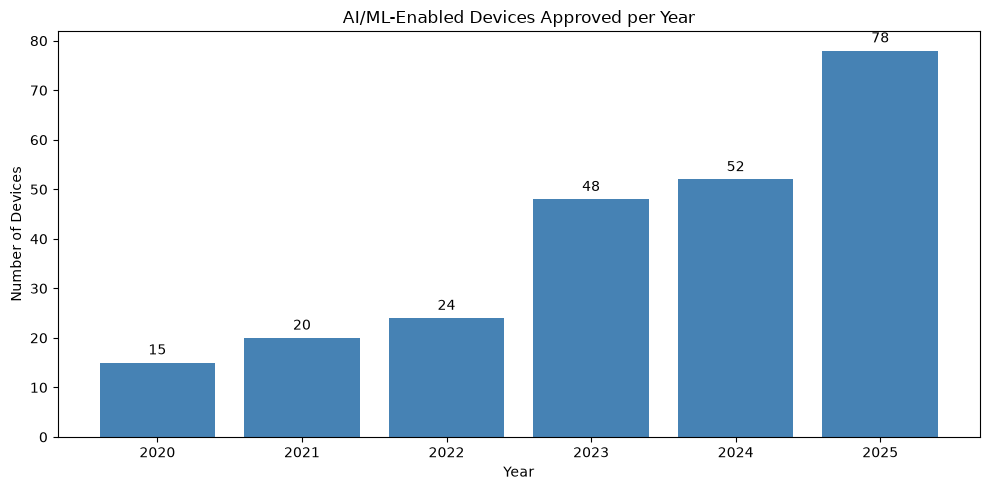

In [9]:

devices_per_year = df.groupby('Year').size().reset_index(name='Count')

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(devices_per_year['Year'], devices_per_year['Count'], color='steelblue')
ax.set_xlabel('Year')
ax.set_ylabel('Number of Devices')
ax.set_title('AI/ML-Enabled Devices Approved per Year')
ax.set_xticks(devices_per_year['Year'])
for bar, count in zip(ax.patches, devices_per_year['Count']):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1,
            str(count), ha='center', va='bottom')
plt.tight_layout()
plt.show()

### Analyze decision summaries

In [10]:
import os
import re

reviews_dir = 'output/reviews'
records = []

def extract_field(field_name, text):
    pattern = r'\|\s*' + re.escape(field_name) + r'\s*\|\s*(.+?)\s*\|'
    m = re.search(pattern, text)
    return m.group(1).strip() if m else None

for submission in sorted(os.listdir(reviews_dir)):
    summary_path = os.path.join(reviews_dir, submission, 'decision_summary.md')
    if not os.path.isfile(summary_path):
        continue

    with open(summary_path) as f:
        text = f.read()

    records.append({
        'submission':      submission,
        'pts_vs_samples':  extract_field('Patients vs. Samples', text),
        'multi_site':      extract_field('Multi-site', text),
        'patients_n':      extract_field('Patients (N)', text),
        'samples_n':       extract_field('Samples (N)', text),
        'demographics':    extract_field('Demographics Disclosed', text),
        'conf_intervals':  extract_field('Confidence Intervals', text),
        'womens_health':   extract_field("Women's Health", text),
    })

summary_df = pd.DataFrame(records)
n_total = len(summary_df)
print(f"Papers with decision_summary.md: {n_total}")

# --- Multiple samples per patient ---
multi_sample_mask = summary_df['pts_vs_samples'].fillna('').str.startswith('Yes')
n_multi_sample    = multi_sample_mask.sum()
pct_multi_sample  = 100 * n_multi_sample / n_total

# --- Multi-site ---
multisite_mask = summary_df['multi_site'].fillna('').str.startswith('Yes')
n_multisite    = multisite_mask.sum()
pct_multisite  = 100 * n_multisite / n_total

# --- Confidence intervals reported ---
ci_mask  = summary_df['conf_intervals'].fillna('').str.lower().str.startswith('yes')
n_ci     = ci_mask.sum()
pct_ci   = 100 * n_ci / n_total

# --- Demographics disclosed ---
demo_mask = summary_df['demographics'].fillna('').str.lower().str.contains('disclosed')
n_demo    = demo_mask.sum()
pct_demo  = 100 * n_demo / n_total

# --- Women's health relevant ---
womens_mask = summary_df['womens_health'].fillna('').str.lower().str.startswith('yes')
n_womens    = womens_mask.sum()
pct_womens  = 100 * n_womens / n_total

rows = [
    ("Multiple samples per patient (pseudoreplication risk)", n_multi_sample, pct_multi_sample),
    ("Multi-site study",                                      n_multisite,    pct_multisite),
    ("Reports confidence intervals",                          n_ci,           pct_ci),
    ("Demographics disclosed",                                n_demo,         pct_demo),
    ("Women's health relevant",                               n_womens,       pct_womens),
]

print("=" * 55)
print(f"{'Metric':<45} {'N':>3}  {'%':>5}")
print("=" * 55)
for label, n, pct in rows:
    print(f"{label:<45} {n:>3}  {pct:>4.1f}%")
print("=" * 55)

# Breakdown of Patients vs. Samples categories
print("\nPatients vs. Samples breakdown:")
pts_cats_clean = summary_df['pts_vs_samples'].fillna('Not reported').apply(lambda x: (
    'Multiple samples per patient' if x.startswith('Yes') else
    'One observation per patient'  if 'one observation' in x.lower() or 'N/A' in x else
    'Not reported'
))
print(pts_cats_clean.value_counts().to_string())

print("\nMulti-site breakdown:")
ms_cats_clean = summary_df['multi_site'].fillna('Not reported').apply(lambda x: (
    'Multi-site'  if x.startswith('Yes') else
    'Single-site' if x.lower().startswith('no') else
    'Not reported'
))
print(ms_cats_clean.value_counts().to_string())


Papers with decision_summary.md: 330
Metric                                          N      %
Multiple samples per patient (pseudoreplication risk)  76  23.0%
Multi-site study                              171  51.8%
Reports confidence intervals                  152  46.1%
Demographics disclosed                        251  76.1%
Women's health relevant                        40  12.1%

Patients vs. Samples breakdown:
pts_vs_samples
One observation per patient     135
Not reported                    119
Multiple samples per patient     76

Multi-site breakdown:
multi_site
Multi-site     171
Single-site    159


### Plot patient N

Studies with parseable patient N : 211
Studies with 'Not reported'       : 119

Distribution of patient N (where reported):
  Min     : 10
  P25     : 82
  Median  : 200
  Mean    : 5,559
  P75     : 592
  Max     : 930,689


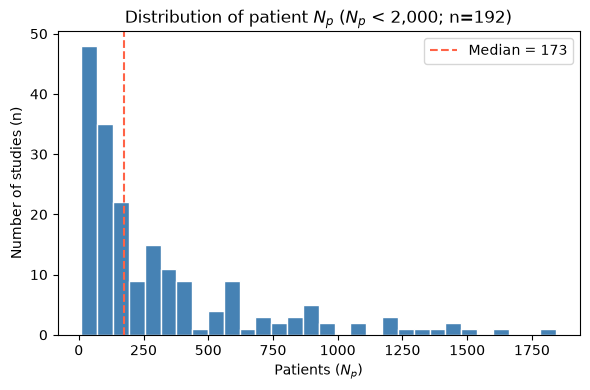


Studies with N > 2,000 (19):
submission                                                                                                                                                                                  patients_n  patients_n_parsed
 DEN240047                                                                                                             Pivotal: 77,511; Reproducibility Study #1: 1,046; Reproducibility Study #2: 102            77511.0
   K240795                                                                                                                                           Training: 11,701; Test: 5089; Clinical Trial: 626             5089.0
   K241891                                                                                                                                                Pivotal: 3,018; Additional Validation: 2,482             2482.0
   K241960                                                                                        

In [11]:
import numpy as np

def parse_patients_n(raw):
    """
    Extract a primary patient N from the raw Patients (N) field.
    Priority: Test > Validation > any labelled cohort > bare number.
    Returns an int or None.
    """
    if not raw or raw.strip().lower().startswith('not reported'):
        return None

    def to_int(s):
        """Strip commas, trailing text like 'patients', and convert to int."""
        s = re.sub(r'[,\s]', '', s.split()[0])
        try:
            return int(s)
        except ValueError:
            return None

    # If the value contains labelled cohorts like "Test: 123; Validation: 456"
    if ':' in raw:
        # Prefer Test, then Validation, then the first labelled number
        for label in ('Test', 'Validation', 'Confirmatory'):
            m = re.search(label + r'[^:]*:\s*([\d,]+)', raw, re.IGNORECASE)
            if m:
                v = to_int(m.group(1))
                if v is not None:
                    return v
        # Fallback: first number after any colon
        m = re.search(r':\s*([\d,]+)', raw)
        if m:
            return to_int(m.group(1))

    # Bare number (possibly with trailing text like "patients", "cases")
    m = re.match(r'^([\d,]+)', raw.replace(' ', ''))
    if m:
        return to_int(m.group(1))

    # e.g. "703 embryos from 59 mothers" — grab first number
    m = re.search(r'([\d,]+)', raw)
    if m:
        return to_int(m.group(1))

    return None


# Parse patient counts from the already-built summary_df
patient_ns = summary_df['patients_n'].apply(parse_patients_n)
summary_df['patients_n_parsed'] = patient_ns

valid = patient_ns.dropna().astype(int)
n_reported   = len(valid)
n_unreported = len(patient_ns) - n_reported

print(f"Studies with parseable patient N : {n_reported}")
print(f"Studies with 'Not reported'       : {n_unreported}")
print()
print("Distribution of patient N (where reported):")
print(f"  Min     : {valid.min():,.0f}")
print(f"  P25     : {valid.quantile(0.25):,.0f}")
print(f"  Median  : {valid.median():,.0f}")
print(f"  Mean    : {valid.mean():,.0f}")
print(f"  P75     : {valid.quantile(0.75):,.0f}")
print(f"  Max     : {valid.max():,.0f}")

# Histogram: zoomed to N < 2000
clipped = valid[valid < 2000]
fig, ax = plt.subplots(figsize=(6, 4))
ax.hist(clipped, bins=30, color='steelblue', edgecolor='white')
ax.set_xlabel('Patients ($N_p$)')
ax.set_ylabel('Number of studies (n)')
ax.set_title(f'Distribution of patient $N_p$ ($N_p$ < 2,000; n={len(clipped)})')
ax.axvline(clipped.median(), color='tomato', linestyle='--', label=f'Median = {clipped.median():,.0f}')
ax.legend()
plt.tight_layout()
plt.show()

# Show the large-N outliers
print(f"\nStudies with N > 2,000 ({len(valid[valid > 2000])}):")
outliers = summary_df[summary_df['patients_n_parsed'] > 2000][['submission', 'patients_n', 'patients_n_parsed']]
print(outliers.to_string(index=False))


In [12]:
total_2025 = 331  # total AI/ML devices approved in 2025 per FDA list

# Submissions in the CSV that are 2025
scraped_submissions = set(os.listdir(reviews_dir))
df_2025 = df[df['Year'] == 2025]
n_2025_csv = len(df_2025)

# How many 2025 submissions have a scraped decision summary
n_scraped_2025 = df_2025['Submission Number'].isin(scraped_submissions).sum()

# All scraped (any year)
n_scraped_any = len(scraped_submissions)

print(f"Total AI/ML devices approved in 2025 (FDA list)  : {total_2025}")
print(f"  In CSV (post-2020 dataset)                      : {n_2025_csv}")
print()
print(f"Decision summary PDFs scraped:")
print(f"  2025 submissions with a scraped summary         : {n_scraped_2025} / {total_2025} ({100*n_scraped_2025/total_2025:.1f}%)")
print(f"  All years with a scraped summary                : {n_scraped_any}")


Total AI/ML devices approved in 2025 (FDA list)  : 331
  In CSV (post-2020 dataset)                      : 78

Decision summary PDFs scraped:
  2025 submissions with a scraped summary         : 77 / 331 (23.3%)
  All years with a scraped summary                : 330


In [13]:
# Women's health relevant devices
wh_mask = summary_df['womens_health'].fillna('').str.lower().str.startswith('yes')
wh_df = summary_df[wh_mask].copy()

# Join with main CSV to get device name, company, panel
wh_df = wh_df.merge(
    df[['Submission Number', 'Device', 'Company', 'Panel (Lead)', 'Date of Final Decision']],
    left_on='submission', right_on='Submission Number', how='left'
)

print(f"Women's health relevant devices: {len(wh_df)} / {len(summary_df)} with decision summaries scraped\n")

# --- Summary statistics for this subset ---
def pct(mask, total):
    n = mask.sum()
    return f"{n} / {total} ({100*n/total:.0f}%)"

n = len(wh_df)
multi_s  = wh_df['pts_vs_samples'].fillna('').str.startswith('Yes')
ms       = wh_df['multi_site'].fillna('').str.startswith('Yes')
ci       = wh_df['conf_intervals'].fillna('').str.lower().str.startswith('yes')
demo     = wh_df['demographics'].fillna('').str.lower().str.contains('disclosed')

print("Properties of women's health devices:")
print(f"  Multiple samples per patient : {pct(multi_s, n)}")
print(f"  Multi-site                   : {pct(ms, n)}")
print(f"  Reports confidence intervals : {pct(ci, n)}")
print(f"  Demographics disclosed       : {pct(demo, n)}")

# --- List of devices ---
print(f"\n{'Submission':<12} {'Device':<55} {'Company':<40} {'Panel'}")
print("-" * 140)
for _, row in wh_df.sort_values('submission').iterrows():
    device  = str(row.get('Device', ''))[:54]
    company = str(row.get('Company', ''))[:39]
    panel   = str(row.get('Panel (Lead)', ''))
    print(f"{row['submission']:<12} {device:<55} {company:<40} {panel}")


Women's health relevant devices: 40 / 330 with decision summaries scraped

Properties of women's health devices:
  Multiple samples per patient : 18 / 40 (45%)
  Multi-site                   : 26 / 40 (65%)
  Reports confidence intervals : 24 / 40 (60%)
  Demographics disclosed       : 33 / 40 (82%)

Submission   Device                                                  Company                                  Panel
--------------------------------------------------------------------------------------------------------------------------------------------
DEN240047    nan                                                     nan                                      nan
K241009      PeriCALM Patterns 3.0                                   PeriGen, Inc.                            Obstetrics and Gynecology
K241671      nan                                                     nan                                      nan
K241949      nan                                                     nan     

In [14]:
# Women's health devices with multiple samples per patient
wh_multi = wh_df[wh_df['pts_vs_samples'].fillna('').str.startswith('Yes')]

print(f"Women's health devices with multiple samples per patient: {len(wh_multi)}\n")
for _, row in wh_multi.sort_values('submission').iterrows():
    print(f"{row['submission']}  {row.get('Device', '')}")
    print(f"  {row['pts_vs_samples']}")
    print()


Women's health devices with multiple samples per patient: 18

DEN240047  nan
  Yes — pseudoreplication risk (multiple observations per patient treated as independent). Quote: 'A random selection of 10 transforms were applied to each of the 102 test exams, yielding 1020 transformed exams for analysis.'

K241949  nan
  Yes — pseudoreplication risk (multiple observations per patient treated as independent)

K242594  nan
  Yes — pseudoreplication risk (multiple observations per patient treated as independent). Each subject contributed multiple images, including standard fetal biometry planes and non-standard views.

K243614  nan
  Yes — pseudoreplication risk (multiple observations per patient treated as independent)

K243679  nan
  Yes — pseudoreplication risk (multiple observations per patient treated as independent)

K243684  nan
  Yes — pseudoreplication risk (multiple observations per patient treated as independent)

K243685  nan
  Yes — pseudoreplication risk (multiple observations p